# Experimento 6: Generación del pool de relaciones a partir de contexto real

En este notebook se construye un pool de relaciones candidatas utilizando como unidad de análisis el modelo de generación de tripletas Rebel.

Se ha utilizado el dataset DicatJuanRana_Dataset.csv

Las relaciones que devuelve Rebel son en ingles. Para buscar los embeddings se usa en nombre en inglés.

Para saber el nombre de la relación en español se han utilizado dos métodos: Un modelo de traducción y llamadas a un llm (grok).

Se utiliza el algoritmo HDBSCAN para clusterizar los embeddings represntativos de las etiquetas.

Para cada cluster encontrado se realiza la busqueda del medoide para encontrar la relación más representativa. El medoide es el punto cuya distancia media al resto es mínima.

Por ello, en este experimento se utiliza:

- modelo Rebel,
- modelo de trtaducción
- llm  (grok)
- embeddings semánticos del contexto,
- clustering no supervisado mediante HDBSCAN.

El objetivo es evaluar si el contexto real mejora la agrupación de verbalizaciones equivalentes y permite obtener un primer pool de relaciones candidatas para la construcción incremental de la ontología.

In [ ]:
# ============================================================
# EXPERIMENTO
# Generación del pool de relaciones a partir de contexto real
# ============================================================
# En esta celda se centralizan los parámetros principales del
# experimento para que el notebook sea más fácil de reproducir
# y modificar.

# Identificador del experimento.
# Se usará como prefijo en los ficheros de salida.
EXPERIMENTO = "Exp06"

# Carpeta donde se guardarán los resultados generados.
OUTPUT_DIR = "../Output/experiments"

# Modelo de embeddings utilizado para representar semánticamente
# las oraciones en las que aparece cada verbo.
MODEL_EMBEDDINGS = "paraphrase-multilingual-MiniLM-L12-v2"

# Parámetros principales de HDBSCAN.
# min_cluster_size define el tamaño mínimo que debe tener un cluster.
MIN_CLUSTER_SIZE = 4

# min_samples controla la exigencia del algoritmo para considerar
# un punto como parte de una zona densa.
MIN_SAMPLES = 2

# Semilla para mantener reproducibilidad en aquellos procesos
# que puedan depender de aleatoriedad.
RANDOM_STATE = 42

In [2]:
# ============================================================
# IMPORTS
# ============================================================

import os
import re

import pandas as pd
import numpy as np

import spacy

from sentence_transformers import SentenceTransformer

import hdbscan

import matplotlib.pyplot as plt


# ============================================================
# CREACIÓN DE CARPETAS DE SALIDA
# ============================================================

# Si la carpeta Outputs no existe, se crea automáticamente.
os.makedirs(OUTPUT_DIR, exist_ok=True)


# ============================================================
# CARGA DEL MODELO DE EMBEDDINGS
# ============================================================

# Modelo multilingüe utilizado para representar semánticamente
# las oraciones extraídas del corpus.
model_embeddings = SentenceTransformer(MODEL_EMBEDDINGS)


print("Configuración cargada correctamente.")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Configuración cargada correctamente.


In [3]:
# ============================================================
# CARGA DEL DATASET
# ============================================================

# Ruta del dataset limpio procedente del TFM anterior.
DATASET_PATH = "../Data/DicatJuanRana_Dataset.csv"

# Carga del CSV.
df = pd.read_csv(DATASET_PATH, sep=";")

print("Dataset cargado correctamente.")
print(f"Número de registros: {len(df)}")
print(f"Número de columnas: {df.shape[1]}")

# Mostrar primeras filas.
df.head()

#print(df_text.loc[0, "clarified_sentences"])



Dataset cargado correctamente.
Número de registros: 38
Número de columnas: 4


,year,text,sentences,clarified_sentences
0,0,"Aunque su verdadero nombre era Cosme Pérez, fu...","[""Aunque su verdadero nombre era Cosme Pérez, ...","[""Aunque su verdadero nombre era Cosme Pérez, ..."
1,1617,"Según Cotarelo , a quien sigue Sáez Raposo , C...","['Según Cotarelo, a quien sigue Sáez Raposo, ...","['Según Cotarelo, a quien sigue Sáez Raposo, S..."
2,1621,Consta la lista de la compañía de Juan Bautist...,['Consta la lista de la compañía de Juan Bauti...,['Consta la lista de la compañía de Juan Bauti...
3,1624,Cosme Pérez aparece en la nómina de la compañí...,['Cosme Pérez aparece en la nómina de la compa...,['Cosme Pérez aparece en la nómina de la compa...
4,1634,"Según Cotarelo, Cosme Pérez pertenecía a la co...","['Según Cotarelo, Cosme Pérez pertenecía a la ...","['Según Cotarelo, Cosme Pérez pertenecía a la ..."


In [4]:
# ============================================================
# SELECCIÓN DE LA COLUMNA TEXTUAL
# ============================================================
# Para este experimento utilizamos la columna clarified_sentences,
# ya que contiene las frases clarificadas del dataset limpio.

TEXT_COLUMN = "clarified_sentences"

# Comprobamos cuántos valores nulos hay en la columna seleccionada.
num_nulls = df[TEXT_COLUMN].isna().sum()

print(f"Columna textual seleccionada: {TEXT_COLUMN}")
print(f"Valores nulos en la columna: {num_nulls}")

# Nos quedamos únicamente con los registros que tienen texto válido.
df_text = df.dropna(subset=[TEXT_COLUMN]).copy()

print(f"Número de registros con texto válido: {len(df_text)}")

df_text[[TEXT_COLUMN]].head()

Columna textual seleccionada: clarified_sentences
Valores nulos en la columna: 0
Número de registros con texto válido: 38


,clarified_sentences
0,"[""Aunque su verdadero nombre era Cosme Pérez, ..."
1,"['Según Cotarelo, a quien sigue Sáez Raposo, S..."
2,['Consta la lista de la compañía de Juan Bauti...
3,['Cosme Pérez aparece en la nómina de la compa...
4,"['Según Cotarelo, Cosme Pérez pertenecía a la ..."


In [5]:
print(df_text.loc[0, TEXT_COLUMN])

["Aunque su verdadero nombre era Cosme Pérez, Cosme Pérez fue conocido artísticamente como 'Juan Rana', según documenta ya la Genealogía —este apodo ya se le aplicaba en 1636—.", 'Aunque Cotarelo aventuró que pudo haber nacido en Madrid, hoy sabemos que Cosme Pérez nació en Tudela de Duero (Valladolid), en cuya iglesia parroquial Cosme Pérez fue bautizado el 7 de abril de 1593.', 'Cosme Pérez fue hijo de Damián Pérez e Isabel de Basto, su segunda esposa, y fue el cuarto de una familia de cuatro hermanos.', 'Según algunas fuentes, como Sánchez Arjona y Subirá, Cosme Pérez estuvo casado con una actriz llamada Bernarda Ramírez.', "Por su lado, Rennert puso en duda el matrimonio de Cosme Pérez con Bernarda Ramírez y creyó más probable que Cosme Pérez estuviese casado con Bernarda Manuela ['la Grifona'], que sería, según esto, la primera mujer de Cosme Pérez.", 'Sin embargo, ambos matrimonios no se encuentran documentados, como ya puso de relieve Cotarelo, y probablemente las deducciones so

In [6]:
# ============================================================
# SEPARACIÓN DE LOS TEXTOS EN FRASES SEPARADAS
# ============================================================

import ast

sentences_data = []

for doc_id, row in df_text.iterrows():

    sentences = row[TEXT_COLUMN]


    # Asegurar lista
    if isinstance(sentences, str):
        sentences = ast.literal_eval(sentences)

    for sent_id, sent in enumerate(sentences):

        sent = sent.strip()

        if sent:

            sentences_data.append({
                "document_id": doc_id,
                "sentence_id": sent_id,
                "sentence": sent
            })

df_sentences = pd.DataFrame(sentences_data)

df_sentences = df_sentences.sort_values(
    by="document_id"
)

#df_sentences.shape
#df_sentences.info()
#df_sentences.head()
##df_sentences[df_sentences["document_id"] == 0].head(10)

print(df_sentences.loc[0, "sentence"])



Aunque su verdadero nombre era Cosme Pérez, Cosme Pérez fue conocido artísticamente como 'Juan Rana', según documenta ya la Genealogía —este apodo ya se le aplicaba en 1636—.


In [14]:
# ============================================================
# EJEMPLO LLAMADA AL MODELO REBEL
# ============================================================

from transformers import AutoModelForSeq2SeqLM, AutoTokenizer

def extract_triplets(text):
    triplets = []
    relation, subject, relation, object_ = '', '', '', ''
    text = text.strip()
    current = 'x'
    for token in text.replace("<s>", "").replace("<pad>", "").replace("</s>", "").split():
        if token == "<triplet>":
            current = 't'
            if relation != '':
                triplets.append({'head': subject.strip(), 'type': relation.strip(),'tail': object_.strip()})
                relation = ''
            subject = ''
        elif token == "<subj>":
            current = 's'
            if relation != '':
                triplets.append({'head': subject.strip(), 'type': relation.strip(),'tail': object_.strip()})
            object_ = ''
        elif token == "<obj>":
            current = 'o'
            relation = ''
        else:
            if current == 't':
                subject += ' ' + token
            elif current == 's':
                object_ += ' ' + token
            elif current == 'o':
                relation += ' ' + token
    if subject != '' and relation != '' and object_ != '':
        triplets.append({'head': subject.strip(), 'type': relation.strip(),'tail': object_.strip()})
    return triplets


    

# Load model and tokenizer
tokenizer = AutoTokenizer.from_pretrained("Babelscape/rebel-large")
model = AutoModelForSeq2SeqLM.from_pretrained("Babelscape/rebel-large")
gen_kwargs = {
    "max_length": 256,
    "length_penalty": 0,
    "num_beams": 3,
    "num_return_sequences": 3,
}


# Text to extract triplets from
text = 'Cosme Pérez fue conocido artísticamente como Juan Rana'

# Tokenizer text
model_inputs = tokenizer(text, max_length=256, padding=True, truncation=True, return_tensors = 'pt')

# Generate
generated_tokens = model.generate(
    model_inputs["input_ids"].to(model.device),
    attention_mask=model_inputs["attention_mask"].to(model.device),
    **gen_kwargs,
)

# Extract text
decoded_preds = tokenizer.batch_decode(generated_tokens, skip_special_tokens=False)

# Extract triplets
for idx, sentence in enumerate(decoded_preds):
    print(f'Prediction triplets sentence {idx}')
    print(extract_triplets(sentence))

for idx, pred in enumerate(decoded_preds):
    print("="*80)
    print(f"PREDICCIÓN {idx}")
    print(pred)






Loading weights:   0%|          | 0/512 [00:00<?, ?it/s]

Prediction triplets sentence 0
[{'head': 'Juan Rana', 'type': 'has part', 'tail': 'Cosme Pérez'}]
Prediction triplets sentence 1
[{'head': 'Juan Rana', 'type': 'performer', 'tail': 'Cosme Pérez'}]
Prediction triplets sentence 2
[{'head': 'Juan Rana', 'type': 'father', 'tail': 'Cosme Pérez'}]
PREDICCIÓN 0
<s><triplet> Juan Rana <subj> Cosme Pérez <obj> has part</s>
PREDICCIÓN 1
<s><triplet> Juan Rana <subj> Cosme Pérez <obj> performer</s><pad>
PREDICCIÓN 2
<s><triplet> Juan Rana <subj> Cosme Pérez <obj> father</s><pad>


In [15]:
# ============================================================
# CONFIGURACION MODELO REBEL
# ============================================================

import pandas as pd
from transformers import AutoModelForSeq2SeqLM, AutoTokenizer


# Load model and tokenizer
tokenizer = AutoTokenizer.from_pretrained("Babelscape/rebel-large")
model = AutoModelForSeq2SeqLM.from_pretrained("Babelscape/rebel-large")
gen_kwargs = {
    "max_length": 256,
    "length_penalty": 0,
    "num_beams": 3,
    "num_return_sequences": 3,
}

def extract_rebel_triplets(text):
    triplets = []
    relation, subject, relation, object_ = '', '', '', ''
    text = text.strip()
    current = 'x'
    for token in text.replace("<s>", "").replace("<pad>", "").replace("</s>", "").split():
        if token == "<triplet>":
            current = 't'
            if relation != '':
                triplets.append({'head': subject.strip(), 'type': relation.strip(),'tail': object_.strip()})
                relation = ''
            subject = ''
        elif token == "<subj>":
            current = 's'
            if relation != '':
                triplets.append({'head': subject.strip(), 'type': relation.strip(),'tail': object_.strip()})
            object_ = ''
        elif token == "<obj>":
            current = 'o'
            relation = ''
        else:
            if current == 't':
                subject += ' ' + token
            elif current == 's':
                object_ += ' ' + token
            elif current == 'o':
                relation += ' ' + token
    if subject != '' and relation != '' and object_ != '':
        triplets.append({'head': subject.strip(), 'type': relation.strip(),'tail': object_.strip()})
    return triplets


def get_rebel_triplets_for_sentence(text):
    model_inputs = tokenizer(
        text,
        max_length=256,
        padding=True,
        truncation=True,
        return_tensors="pt"
    )

    generated_tokens = model.generate(
        model_inputs["input_ids"].to(model.device),
        attention_mask=model_inputs["attention_mask"].to(model.device),
        max_length=256,
        length_penalty=0,
        num_beams=3,
        num_return_sequences=3
    )

    decoded_preds = tokenizer.batch_decode(
        generated_tokens,
        skip_special_tokens=False
    )

    triplets = [
        extract_rebel_triplets(pred)
        for pred in decoded_preds
    ]

    return triplets

Loading weights:   0%|          | 0/512 [00:00<?, ?it/s]

In [16]:
# ============================================================
# EJECUCION DEL MODEL REBEL PARA SACAR LAS TRIPLETAS DE CADA FRASE
# ============================================================

df_sentences["rebel_outputs"] = df_sentences["sentence"].apply(
    get_rebel_triplets_for_sentence
)



In [17]:
# ============================================================
# GUARDAR DATAFTAME df_sentences A FICHERO
# ============================================================

from datetime import datetime

timestamp = datetime.now().strftime(
    "%Y%m%d_%H%M%S"
)

filename = (
    f"{OUTPUT_DIR}/df_sentences_rebel_{timestamp}.pkl"
)

df_sentences.to_pickle(filename)

print(f"Guardado en: {filename}")


Guardado en: ../Output/experiments/df_sentences_rebel_20260518_131952.pkl


In [15]:
df_sentences.head()
print(df_sentences.loc[0, "rebel_outputs"])


[[{'head': '1636', 'type': 'point in time', 'tail': '1636'}], [{'head': 'Genealogía', 'type': 'subclass of', 'tail': 'documenta'}], [{'head': 'Genealogía', 'type': 'instance of', 'tail': 'documenta'}]]


In [ ]:
# ============================================================
# LEER DATAFTAME df_sentences DE FICHERO
# 
#  Este punto solo se ejecuta si se quiere partir de alguna ejecución anterior y no se quieren repetir pasos ya realizados.
# ============================================================

df_sentences = pd.read_pickle(
    f"{OUTPUT_DIR}/df_sentences_rebel_20260518_131952.pkl"
)

In [8]:
# ============================================================
# SELECCION DE LAS TRIPLETAS UNICAS PARA CADA FRASE
# ============================================================

def merge_unique_triplets(predictions):

    all_triplets = []

    # Unimos todas las tripletas de las 3 predicciones
    for pred in predictions:
        all_triplets.extend(pred)


    # Eliminamos duplicados
    unique_triplets = {
        (
            t["head"],
            t["tail"],
            t["type"]
        ): t
        for t in all_triplets
    }

    return list(unique_triplets.values())

df_sentences["triplets_merged"] = df_sentences[
    "rebel_outputs"
].apply(merge_unique_triplets)

In [9]:
## print(df_sentences.loc[0, "sentence"])
## print(df_sentences.loc[0, "triplets_merged"])
df_sentences.columns

Index(['document_id', 'sentence_id', 'sentence', 'rebel_outputs',
       'triplets_merged'],
      dtype='object')

In [10]:
# ============================================================
# CREACION DATAFRAME df_triplets CON TODAS LAS TRIPLETAS OBTENIDAS
# ============================================================

triplet_rows = []

for _, row in df_sentences.iterrows():

    triplets = row["triplets_merged"]

    for triplet in triplets:

        triplet_rows.append({
            "document_id": row["document_id"],
            "sentence_id": row["sentence_id"],
            "sentence": row["sentence"],
            "head": triplet.get("head"),
            "tail": triplet.get("tail"),
            "relation": triplet.get("type")
        })

df_triplets = pd.DataFrame(triplet_rows)

df_triplets.head()

,document_id,sentence_id,sentence,head,tail,relation
0,0,0,"Aunque su verdadero nombre era Cosme Pérez, Co...",1636,1636,point in time
1,0,0,"Aunque su verdadero nombre era Cosme Pérez, Co...",Genealogía,documenta,subclass of
2,0,0,"Aunque su verdadero nombre era Cosme Pérez, Co...",Genealogía,documenta,instance of
3,0,1,Aunque Cotarelo aventuró que pudo haber nacido...,Tudela de Duero,Valladolid,located in the administrative territorial entity
4,0,1,Aunque Cotarelo aventuró que pudo haber nacido...,Valladolid,Tudela de Duero,contains administrative territorial entity


In [25]:
print(f"Número total de tripletas: {len(df_triplets)}")

Número total de tripletas: 1168


In [11]:
# ============================================================
# CREACION TEXTO CON EL QUE SE OBTENDRAN LOS EMBEDDINGS
# ============================================================

# Para obtener el embedding se añade a la relación el nombre completo del sujeto y del objeto
df_triplets["texto_embedding"] = (
    df_triplets["head"] + " " +
    df_triplets["relation"] + " " +
    df_triplets["tail"]
)

df_triplets.head()
#df_triplets.shape

,document_id,sentence_id,sentence,head,tail,relation,texto_embedding
0,0,0,"Aunque su verdadero nombre era Cosme Pérez, Co...",1636,1636,point in time,1636 point in time 1636
1,0,0,"Aunque su verdadero nombre era Cosme Pérez, Co...",Genealogía,documenta,subclass of,Genealogía subclass of documenta
2,0,0,"Aunque su verdadero nombre era Cosme Pérez, Co...",Genealogía,documenta,instance of,Genealogía instance of documenta
3,0,1,Aunque Cotarelo aventuró que pudo haber nacido...,Tudela de Duero,Valladolid,located in the administrative territorial entity,Tudela de Duero located in the administrative ...
4,0,1,Aunque Cotarelo aventuró que pudo haber nacido...,Valladolid,Tudela de Duero,contains administrative territorial entity,Valladolid contains administrative territorial...


In [32]:
df_triplets.iloc[7]["texto_embedding"]

'Damián Pérez child Cosme Pérez'

In [19]:
# ============================================================
# OBTENCION EMBEDDINGS
# ============================================================

texts = df_triplets["texto_embedding"].tolist()

embeddings = model_embeddings.encode(
    texts,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True
)

print("Embeddings generados correctamente.")
print(f"Número de embeddings: {embeddings.shape[0]}")
print(f"Dimensión de cada embedding: {embeddings.shape[1]}")

df_triplets["embedding"] = list(embeddings)



Batches:   0%|          | 0/37 [00:00<?, ?it/s]

Embeddings generados correctamente.
Número de embeddings: 1168
Dimensión de cada embedding: 384


In [12]:
# ============================================================
# CONFIGURACION MODELO PARA OBTENER LA TRADUCCION AL ESPAÑOL DE LA RELACION
# ============================================================

from transformers import MarianMTModel, MarianTokenizer

translator_tokenizer = MarianTokenizer.from_pretrained(
    "Helsinki-NLP/opus-mt-en-es"
)

translator_model = MarianMTModel.from_pretrained(
    "Helsinki-NLP/opus-mt-en-es"
)


def translate_text(text):

    inputs = translator_tokenizer(
        text,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=128
    )

    translated_tokens = translator_model.generate(
        **inputs,
        max_length=128
    )

    return translator_tokenizer.decode(
        translated_tokens[0],
        skip_special_tokens=True
    )





c:\Users\xavie\anaconda3\envs\spacy_env\lib\site-packages\transformers\models\marian\tokenization_marian.py:176: UserWarning: Recommended: pip install sacremoses.
  warnings.warn("Recommended: pip install sacremoses.")


Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

In [13]:
# ============================================================
# METODOS PARA OBTENER LA TRADUCCION AL ESPAÑOL DE LA RELACION
# ============================================================

# Para obtener la relacion se crean una marcas ficticias para aislar la relacion
def extract_between_markers(text):
    start = "AAA"
    end = "BBB"

    if start in text and end in text:
        return text.split(start, 1)[1].split(end, 1)[0].strip(" .,:;")

    return text.strip(" .,:;")
    
def translate_relation_with_model_with_marks(row):

    text = (
        f"In a knowledge graph, a {row['head']} entity "
        f"AAA {row['relation']} BBB "
        f"a {row['tail']} entity."
    )

    translated = translate_text(text)

    return extract_between_markers(translated)

In [14]:
# ============================================================
# OBTENCION TRADUCCION AL ESPAÑOL DE LA RELACION CON MODELO TRADUCTOR
# ============================================================

import time

inicio = time.time()

df_triplets["relation_es_translator_marks"] = df_triplets.apply(
    translate_relation_with_model_with_marks,
    axis=1
)

fin = time.time()

tiempo = fin - inicio

minutos = int(tiempo // 60)
segundos = tiempo % 60

print(f"Tiempo de ejecución: {minutos} min {segundos:.2f} s")

Tiempo de ejecución: 19 min 40.82 s


In [15]:
#df_triplets.head(5)
print(df_triplets.loc[10, "relation_es_translator_marks"])

hijo


In [16]:
# ============================================================
# CONFIGURACION GROQ API (LLM) PARA OBTENCION TRADUCCION AL ESPAÑOL DE LA RELACION
# ============================================================

from openai import OpenAI

client = OpenAI(
    api_key="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",
    base_url="https://api.groq.com/openai/v1"
)

In [17]:
# ============================================================
# LLAMADA AL LLM
# ============================================================

def call_llm(prompt):

    response = client.chat.completions.create(
        model="llama-3.1-8b-instant",
        messages=[
            {
                "role": "user",
                "content": prompt
            }
        ],
        temperature=0
    )

    return response.choices[0].message.content.strip()


def translate_relation_llm(row):

    prompt = f"""
Translate the following ontology relation into concise Spanish.

Subject: {row['head']}
Relation: {row['relation']}
Object: {row['tail']}

Return ONLY the Spanish relation label.
"""

    return call_llm(prompt)

In [18]:
# ============================================================
# OBTENCION TRADUCCION AL ESPAÑOL DE LA RELACION CON LLM
# ============================================================

import time

inicio = time.time()

df_triplets["relation_es_llm"] = df_triplets.apply(
    translate_relation_llm,
    axis=1
)

fin = time.time()

tiempo = fin - inicio

minutos = int(tiempo // 60)
segundos = tiempo % 60

print(f"Tiempo de ejecución: {minutos} min {segundos:.2f} s")

Tiempo de ejecución: 42 min 20.32 s


In [19]:
print(df_triplets.loc[10, "relation_es_llm"])

Hija


In [37]:
# ============================================================
# GUARDAR DATAFTAME df_triplets A FICHERO
# ============================================================
from datetime import datetime

timestamp = datetime.now().strftime(
    "%Y%m%d_%H%M%S"
)

filename = (
    f"{OUTPUT_DIR}/df_triplets_rebel_{timestamp}.pkl"
)

df_triplets.to_pickle(filename)

print(f"Guardado en: {filename}")

Guardado en: ../Output/experiments/df_triplets_rebel_20260518_151635.pkl


In [ ]:
# ============================================================
# LEER DATAFTAME df_sentences DE FICHERO
# 
#  Este punto solo se ejecuta si se quiere partir de alguna ejecución anterior y no se quieren repetir pasos ya realizados.
# ============================================================

df_triplets = pd.read_pickle(
    f"{OUTPUT_DIR}/df_triplets_rebel_20260518_151635.pkl"
)

embeddings = np.array(df_triplets["embedding"].tolist())

In [16]:
df_triplets.columns

Index(['document_id', 'sentence_id', 'sentence', 'head', 'tail', 'relation',
       'texto_embedding', 'embedding', 'cluster'],
      dtype='object')

In [4]:
# ============================================================
# CLUSTERING SEMÁNTICO CON HDBSCAN
# ============================================================
# Aplicamos HDBSCAN sobre los embeddings generados a partir
# del contexto oracional de cada relación verbal.

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=MIN_CLUSTER_SIZE,
    min_samples=MIN_SAMPLES,
    metric="euclidean"
)

clusters = clusterer.fit_predict(embeddings)

# Añadimos los clusters al dataframe.
df_triplets["cluster"] = clusters

print("Clustering completado correctamente.")

# ============================================================
# MÉTRICAS GENERALES
# ============================================================

total_relaciones = len(df_triplets)

# Número de clusters reales (excluyendo ruido = -1)
total_clusters = len(set(clusters)) - (1 if -1 in clusters else 0)

# Número de relaciones clasificadas como ruido
total_noise = (clusters == -1).sum()

# Porcentaje de ruido
noise_percentage = round(
    total_noise / total_relaciones * 100,
    2
)

print(f"Relaciones analizadas: {total_relaciones}")
print(f"Clusters detectados: {total_clusters}")
print(f"Relaciones clasificadas como ruido: {total_noise}")
print(f"Porcentaje de ruido: {noise_percentage}%")

Clustering completado correctamente.
Relaciones analizadas: 1168
Clusters detectados: 94
Relaciones clasificadas como ruido: 492
Porcentaje de ruido: 42.12%


In [21]:
# ============================================================
# INSPECCIÓN DE CLUSTERS
# ============================================================
# Mostramos las relaciones agrupadas en cada cluster
# para analizar coherencia semántica.

for cluster_id in sorted(df_triplets["cluster"].unique()):

    # Ignoramos ruido
    if cluster_id == -1:
        continue

    print("=" * 60)
    print(f"CLUSTER {cluster_id}")
    print("=" * 60)

    cluster_data = df_triplets[
        df_triplets["cluster"] == cluster_id
    ]

    relaciones_traductor = sorted(
        cluster_data["relation_es_translator_marks"].unique()
    )

    relaciones_llm = sorted(
        cluster_data["relation_es_llm"].unique()
    )

    print(f"\nRelaciones traductor: {relaciones_traductor[:30]}")
    print(f"Relaciones llm: {relaciones_llm[:30]}")

    print(f"\nNúmero de relaciones: {len(cluster_data)}")
    print(f"Número relaciones únicas traductor: {len(relaciones_traductor)}")
    print(f"Número relaciones únicas llm: {len(relaciones_llm)}")

    print("\n")

CLUSTER 0

Relaciones traductor: ['diferente de', 'frente a']
Relaciones llm: ['"opuesto a"', 'Oposición', 'distinto de', 'opuesto a']

Número de relaciones: 8
Número relaciones únicas traductor: 2
Número relaciones únicas llm: 4


CLUSTER 1

Relaciones traductor: ['dijo que era la misma que', 'llamada así por', 'nombrado por']
Relaciones llm: ['"Es la misma que"', '"Nombre de"', '"Nombreado en honor a"', 'Igual a']

Número de relaciones: 4
Número relaciones únicas traductor: 3
Número relaciones únicas llm: 4


CLUSTER 2

Relaciones traductor: ['de', 'subclase de', 'tiene parte']
Relaciones llm: ['"es una subclase de"', 'La relación es: "instancia de"', 'Tiene parte']

Número de relaciones: 5
Número relaciones únicas traductor: 3
Número relaciones únicas llm: 3


CLUSTER 3

Relaciones traductor: ['capital']
Relaciones llm: ['Capital']

Número de relaciones: 4
Número relaciones únicas traductor: 1
Número relaciones únicas llm: 1


CLUSTER 4

Relaciones traductor: ['país']
Relaciones llm

In [23]:
pd.set_option("display.max_colwidth", None)


In [24]:
df_triplets[
    df_triplets["cluster"] == 14
][[
    "sentence",
    "relation_es_translator_marks",
    "relation_es_llm",
    "relation",
    "head",
    "tail"

]]

,sentence,relation_es_translator_marks,relation_es_llm,relation,head,tail
349,"Pedro, hijo de los actores Pedro de la Rosa y Catalina Nicolás, su mujer, que vivían en la calle de las Comedias, fue bautizado en la iglesia de Nuestra Señora de San Lorenzo de Valladolid, actuando como padrinos los actores Antonio de Vitoria y Josefa Román, y como testigos los actores Cosme Pérez y Antonio Ramos.",cónyuge,Esposo/a,spouse,Antonio de Vitoria,Josefa Román
350,"Pedro, hijo de los actores Pedro de la Rosa y Catalina Nicolás, su mujer, que vivían en la calle de las Comedias, fue bautizado en la iglesia de Nuestra Señora de San Lorenzo de Valladolid, actuando como padrinos los actores Antonio de Vitoria y Josefa Román, y como testigos los actores Cosme Pérez y Antonio Ramos.",cónyuge,Esposa,spouse,Josefa Román,Antonio de Vitoria
351,"Pedro, hijo de los actores Pedro de la Rosa y Catalina Nicolás, su mujer, que vivían en la calle de las Comedias, fue bautizado en la iglesia de Nuestra Señora de San Lorenzo de Valladolid, actuando como padrinos los actores Antonio de Vitoria y Josefa Román, y como testigos los actores Cosme Pérez y Antonio Ramos.",hermano,Hermano(a),sibling,Antonio de Vitoria,Josefa Román
352,"Pedro, hijo de los actores Pedro de la Rosa y Catalina Nicolás, su mujer, que vivían en la calle de las Comedias, fue bautizado en la iglesia de Nuestra Señora de San Lorenzo de Valladolid, actuando como padrinos los actores Antonio de Vitoria y Josefa Román, y como testigos los actores Cosme Pérez y Antonio Ramos.",hermano,Hermano(a),sibling,Josefa Román,Antonio de Vitoria
357,"actuando como padrinos los actores Antonio de Vitoria y Josefa Román,",cónyuge,Esposo/a,spouse,Antonio de Vitoria,Josefa Román
358,"actuando como padrinos los actores Antonio de Vitoria y Josefa Román,",cónyuge,Esposa,spouse,Josefa Román,Antonio de Vitoria


In [25]:
pd.reset_option("display.max_colwidth")

In [26]:
# ============================================================
# MÉTRICAS BÁSICAS DE CLUSTERS
# ============================================================
# Calculamos métricas básicas para analizar el comportamiento
# de los clusters generados por HDBSCAN.

cluster_metrics = []

# Recorremos todos los clusters excepto ruido (-1).
for cluster_id in sorted(df_triplets["cluster"].unique()):

    if cluster_id == -1:
        continue

    cluster_data = df_triplets[
        df_triplets["cluster"] == cluster_id
    ]

    # Número total de relaciones en el cluster.
    total_relaciones_cluster = len(cluster_data)


     # Número de relaciones únicas.
    relaciones_unicas = cluster_data["relation"].nunique()

    # Frecuencia media de reutilización con traductor.
    frecuencia_media = (
        total_relaciones_cluster / relaciones_unicas
    )

    # Lista de relaciones del cluster.
    lista_relaciones = sorted(
        cluster_data["relation"].unique()
    )

    cluster_metrics.append({
        "cluster": cluster_id,
        "num_relaciones": total_relaciones_cluster,
        "num_relaciones_unicas": relaciones_unicas,
        "frecuencia_media": round(frecuencia_media, 2),
        "relaciones": ", ".join(lista_relaciones[:100])
    })

# Convertimos a dataframe.
df_cluster_metrics = pd.DataFrame(cluster_metrics)

# Ordenamos por tamaño del cluster.
df_cluster_metrics = df_cluster_metrics.sort_values(
    by="num_relaciones",
    ascending=False
).reset_index(drop=True)

print("Métricas de clusters calculadas correctamente.")

df_cluster_metrics.head(10)

Métricas de clusters calculadas correctamente.


,cluster,num_relaciones,num_relaciones_unicas,frecuencia_media,relaciones
0,67,46,18,2.56,"chairperson, conferred by, employer, founded b..."
1,68,23,3,7.67,"occupation, officeholder, position held"
2,92,20,8,2.50,"author, cast member, chairperson, creator, dep..."
3,13,18,2,9.00,"contains administrative territorial entity, tw..."
4,63,16,5,3.20,"has part, instance of, located in the administ..."
5,71,15,4,3.75,located in the administrative territorial enti...
6,60,14,2,7.00,located in the administrative territorial enti...
7,47,12,7,1.71,"author, composer, creator, director, genre, li..."
8,45,11,1,11.00,spouse
9,78,11,2,5.50,"has part, spouse"


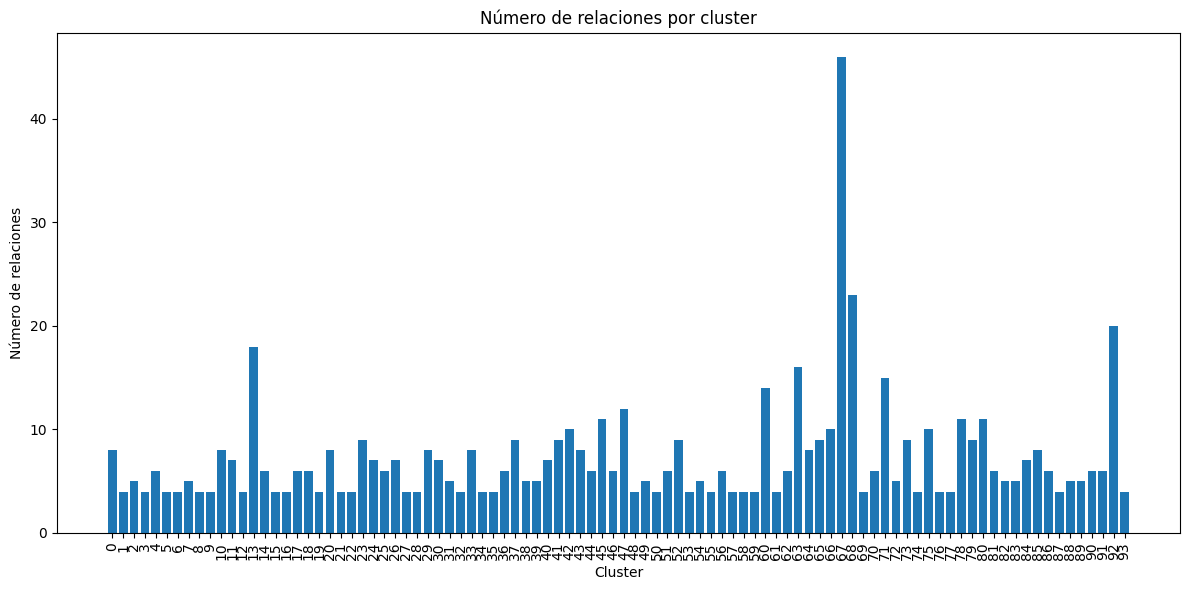

In [27]:
# ============================================================
# TAMAÑO DE LOS CLUSTERS
# ============================================================
# Visualización del número de relaciones detectadas
# en cada cluster generado por HDBSCAN.

# Ordenamos clusters por tamaño.
df_plot = df_cluster_metrics.sort_values(
    by="cluster",
    ascending=True
)

plt.figure(figsize=(12, 6))

plt.bar(
    df_plot["cluster"].astype(str),
    df_plot["num_relaciones"]
)

plt.title("Número de relaciones por cluster")
plt.xlabel("Cluster")
plt.ylabel("Número de relaciones")

plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

In [28]:
# ============================================================
# COHERENCIA SEMÁNTICA INTRA-CLUSTER
# ============================================================
# Calculamos la similitud media entre los embeddings de cada cluster.
#
# Importante:
# Cada embedding se asocia explícitamente a su fila correspondiente
# para evitar desalineaciones entre índices del dataframe y posiciones
# del array de embeddings.

from sklearn.metrics.pairwise import cosine_similarity

# Guardamos cada embedding dentro del dataframe de relaciones.
# Esto garantiza que cada fila conserva su representación vectorial.

cluster_coherence = []

for cluster_id in sorted(df_triplets["cluster"].unique()):

    # Ignoramos el ruido.
    if cluster_id == -1:
        continue

    # Filtramos las relaciones pertenecientes al cluster actual.
    cluster_data = df_triplets[
        df_triplets["cluster"] == cluster_id
    ]

    # Recuperamos los embeddings asociados a esas filas.
    cluster_embeddings = np.vstack(
        cluster_data["embedding"].values
    )

    # Si el cluster tiene menos de 2 elementos, no se puede calcular coherencia.
    if len(cluster_embeddings) < 2:
        coherence = np.nan
    else:
        sim_matrix = cosine_similarity(cluster_embeddings)

        # Extraemos solo la parte superior de la matriz, excluyendo la diagonal.
        # Así evitamos comparar cada embedding consigo mismo.
        sim_values = sim_matrix[
            np.triu_indices_from(sim_matrix, k=1)
        ]

        coherence = sim_values.mean()

    cluster_coherence.append({
        "cluster": cluster_id,
        "coherencia_semantica": coherence
    })

df_cluster_coherence = pd.DataFrame(cluster_coherence)

# Eliminamos una posible columna previa de coherencia si la celda se reejecuta.
df_cluster_metrics = df_cluster_metrics.drop(
    columns=["coherencia_semantica"],
    errors="ignore"
)

# Unimos la coherencia con las métricas básicas de cluster.
df_cluster_metrics = df_cluster_metrics.merge(
    df_cluster_coherence,
    on="cluster",
    how="left"
)

# Ordenamos por coherencia semántica.
df_cluster_metrics = df_cluster_metrics.sort_values(
    by="coherencia_semantica",
    ascending=True
).reset_index(drop=True)

df_cluster_metrics.head(15)


,cluster,num_relaciones,num_relaciones_unicas,frecuencia_media,relaciones,coherencia_semantica
0,2,5,3,1.67,"has part, instance of, subclass of",0.599090
1,24,7,4,1.75,"member of, member of political party, occupati...",0.670561
2,6,4,3,1.33,"instance of, part of, subclass of",0.673985
3,43,8,4,2.00,"different from, employer, located in the admin...",0.705580
4,20,8,4,2.00,"date of death, end time, point in time, start ...",0.718787
5,17,6,2,3.00,"sibling, spouse",0.720063
6,13,18,2,9.00,"contains administrative territorial entity, tw...",0.723245
7,5,4,3,1.33,"genre, instance of, occupation",0.726091
8,10,8,2,4.00,"has part, part of",0.737147
9,66,10,4,2.50,"child, family, mother, spouse",0.740115


In [29]:
df_cluster_metrics.head(15)
#df_cluster_metrics.tail(15)

,cluster,num_relaciones,num_relaciones_unicas,frecuencia_media,relaciones,coherencia_semantica
0,2,5,3,1.67,"has part, instance of, subclass of",0.599090
1,24,7,4,1.75,"member of, member of political party, occupati...",0.670561
2,6,4,3,1.33,"instance of, part of, subclass of",0.673985
3,43,8,4,2.00,"different from, employer, located in the admin...",0.705580
4,20,8,4,2.00,"date of death, end time, point in time, start ...",0.718787
5,17,6,2,3.00,"sibling, spouse",0.720063
6,13,18,2,9.00,"contains administrative territorial entity, tw...",0.723245
7,5,4,3,1.33,"genre, instance of, occupation",0.726091
8,10,8,2,4.00,"has part, part of",0.737147
9,66,10,4,2.50,"child, family, mother, spouse",0.740115


In [5]:
# ============================================================
# BUSQUEDA PARA CADA CLUSTER DEL MEDOID
# ============================================================

## eL MEDOID ES el embedding cuya distancia media al resto es mínima

import numpy as np
from sklearn.metrics.pairwise import cosine_distances


def assign_cluster_medoids(df_triplets):
    """
    Añade una columna 'relation_elected' al dataframe.
    
    - 'SI'  -> relación medoid del cluster
    - 'NO'  -> resto de relaciones del cluster
    - ruido (-1) -> siempre 'SI'
    
    Requiere:
    - columna 'embedding'
    - columna 'cluster'
    """

    # Inicializar columna
    df_triplets["relation_elected"] = "NO"

    # Obtener clusters únicos
    clusters = df_triplets["cluster"].unique()

    for cluster_id in clusters:

        # Caso ruido
        if cluster_id == -1:
            df_triplets.loc[
                df_triplets["cluster"] == -1,
                "relation_elected"
            ] = "SI"

            continue

        # Filas del cluster
        cluster_df = df_triplets[
            df_triplets["cluster"] == cluster_id
        ]

        # Obtener embeddings
        embeddings = np.array(
            cluster_df["embedding"].tolist()
        )

        # Calcular matriz de distancias coseno
        dist_matrix = cosine_distances(embeddings)

        # Distancia media de cada embedding al resto
        avg_distances = dist_matrix.mean(axis=1)

        # Índice del medoid (mínima distancia media)
        medoid_local_idx = np.argmin(avg_distances)

        # Índice real dentro del dataframe original
        medoid_global_idx = cluster_df.index[medoid_local_idx]

        # Marcar medoid como SI
        df_triplets.loc[
            medoid_global_idx,
            "relation_elected"
        ] = "SI"

    return df_triplets

df_triplets = assign_cluster_medoids(df_triplets)

In [6]:
num_relations_selected = (
    df_triplets["relation_elected"] == "SI"
).sum()

print(num_relations_selected)

586


In [8]:
for cluster_id in sorted(df_triplets["cluster"].unique()):

    # Ignorar ruido
    if cluster_id == -1:
        continue

    print("=" * 60)
    print(f"CLUSTER {cluster_id}")
    print("=" * 60)

    # Datos del cluster
    cluster_data = df_triplets[
        df_triplets["cluster"] == cluster_id
    ]

    # Relaciones únicas
    relaciones_traductor = sorted(
        cluster_data["relation_es_translator_marks"].unique()
    )

    relaciones_llm = sorted(
        cluster_data["relation_es_llm"].unique()
    )

    # Relación elegida (medoid)
    relacion_elegida = cluster_data[
        cluster_data["relation_elected"] == "SI"
    ]

    # Mostrar relaciones agrupadas
    print(f"\nRelaciones traductor: {relaciones_traductor[:30]}")
    print(f"Relaciones llm: {relaciones_llm[:30]}")

    # Mostrar relación elegida
    print("\nRelación elegida:")

    for _, row in relacion_elegida.iterrows():

        print(
            f"- {row['head']} -- "
            f"{row['relation']} -- "
            f"{row['tail']} "
            f"| traductor: {row['relation_es_translator_marks']} "
            f"| llm: {row['relation_es_llm']}"
        )

    # Estadísticas
    print(f"\nNúmero de relaciones: {len(cluster_data)}")

    print(
        f"Número relaciones únicas traductor: "
        f"{len(relaciones_traductor)}"
    )

    print(
        f"Número relaciones únicas llm: "
        f"{len(relaciones_llm)}"
    )

    print("\n")

CLUSTER 0

Relaciones traductor: ['diferente de', 'frente a']
Relaciones llm: ['"opuesto a"', 'Oposición', 'distinto de', 'opuesto a']

Relación elegida:
- complemento indirecto -- different from -- complemento directo | traductor: diferente de | llm: distinto de

Número de relaciones: 8
Número relaciones únicas traductor: 2
Número relaciones únicas llm: 4


CLUSTER 1

Relaciones traductor: ['dijo que era la misma que', 'llamada así por', 'nombrado por']
Relaciones llm: ['"Es la misma que"', '"Nombre de"', '"Nombreado en honor a"', 'Igual a']

Relación elegida:
- Santa Ana -- named after -- Ana | traductor: llamada así por | llm: "Nombreado en honor a"

Número de relaciones: 4
Número relaciones únicas traductor: 3
Número relaciones únicas llm: 4


CLUSTER 2

Relaciones traductor: ['de', 'subclase de', 'tiene parte']
Relaciones llm: ['"es una subclase de"', 'La relación es: "instancia de"', 'Tiene parte']

Relación elegida:
- representaciones seguidas -- subclass of -- treinta | traduct